# Notebook 3 - Feature Engineering & EDA Synthesis

**Course:** Data Engineering - Unsupervised Learning Project  
**University:** Bar-Ilan University, Spring 2026  
**Dataset:** NYC PLUTO - 858,644 lots/buildings across New York City  

## Sections Covered
- [x] **Section 6** - Feature Engineering: new features, log transforms, categorical encoding, standardisation  
- [x] **Section 7** - Unbalanced Data: borough and land-use distributions  
- [x] **Section 8** - Final Synthesis & Preprocessing Recommendations  

## Research Question
> *How can we build, from the physical, functional and geographical characteristics
> of the PLUTO dataset, an unsupervised segmentation of NYC buildings to identify
> homogeneous urban profiles and analyze their distribution across the five boroughs?*

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

FIGURES_DIR = 'reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

In [2]:
df = pd.read_csv('data/raw/pluto_working_copy.csv', low_memory=False)
print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

# The raw CSV uses a Narrow No-Break Space (U+202F) as a thousands separator
# (e.g. "2660" is stored as "2 660"). This is a French locale export format.
# pandas 3.x reads these as dtype 'str' (not 'object'), so we use is_string_dtype()
# to detect them, strip all non-numeric characters, then cast to float.
numeric_cols = ['yearbuilt', 'lotarea', 'bldgarea', 'numfloors',
                'lotfront', 'lotdepth', 'unitstotal', 'unitsres',
                'resarea', 'comarea', 'officearea', 'retailarea',
                'garagearea', 'strgearea', 'assesstot']
for col in numeric_cols:
    if col in df.columns and pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].astype(str).str.replace(r'[^\d.-]', '', regex=True)
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.head(3)

Dataset loaded: 858,644 rows, 101 columns


,borough,Tax block,Tax lot,community board,census tract 2010,cb2010,schooldist,council district,postcode,firecomp,...,bctcb2020,geom,basempdate,dcasdate,edesigdate,landmkdate,masdate,polidate,rpaddate,zoningdate
0,QN,6173,23,411.0,1123,1002.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,QN,6173,24,411.0,1123,1002.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,QN,6169,26,411.0,1123,2000.0,26.0,19.0,11361.0,E306,...,4.112300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Context Recap

The 20 features selected in Part 1 are split into two roles:

| Group | Features | Role in the model |
|---|---|---|
| Physical (6) | `lotarea`, `bldgarea`, `numfloors`, `lotfront`, `lotdepth`, `yearbuilt` | K-Means input |
| Functional (9) | `landuse`, `unitstotal`, `unitsres`, `resarea`, `comarea`, `officearea`, `retailarea`, `garagearea`, `strgearea` | K-Means input |
| Geographical (5) | `borough`, `zipcode`, `cd`, `latitude`, `longitude` | Post-clustering interpretation only |

> **Methodological note:** `assesstot` (total assessed value) is deliberately excluded
> from K-Means input to avoid value-based segmentation (which would reduce the problem
> to a form of regression). It is kept for post-clustering interpretation only.

---
# Section 6: Feature Engineering

This section enriches the dataset with derived features that better capture the structural
and functional reality of NYC buildings. We also demonstrate the transformations needed
to make numerical features suitable for distance-based algorithms.

## 6.1: New Engineered Features

We create 4 new features, each with a clear analytical justification:

| Feature | Formula | Justification |
|---|---|---|
| `building_age` | `2026 - yearbuilt` | More interpretable than a raw year; directly measures temporal context and structural era |
| `building_density` | `bldgarea / lotarea` | Measures how intensively a lot is built upon - a key urban form indicator |
| `residential_ratio` | `unitsres / unitstotal` | Captures building character: 0 = purely commercial, 1 = purely residential |
| `value_per_sqft` | `assesstot / bldgarea` | **Post-clustering only** - normalised property value for cluster profiling |

**Edge cases handled:**
- `yearbuilt == 0` encodes an unknown year in the PLUTO data dictionary → `building_age = NaN`
- Division by zero in ratio features → `NaN` (using `np.where`) instead of `Inf`

In [3]:
# --- building_age -------------------------------------------------------
# yearbuilt == 0 means the construction year is unknown (PLUTO data dictionary)
df['building_age'] = 2026 - df['yearbuilt']
df.loc[df['yearbuilt'] == 0, 'building_age'] = np.nan

# --- building_density ---------------------------------------------------
# Ratio of total built surface to lot surface; undefined when lot has no area
df['building_density'] = np.where(
    df['lotarea'] > 0,
    df['bldgarea'] / df['lotarea'],
    np.nan
)

# --- residential_ratio --------------------------------------------------
# Share of residential units; undefined for buildings with zero total units
df['residential_ratio'] = np.where(
    df['unitstotal'] > 0,
    df['unitsres'] / df['unitstotal'],
    np.nan
)

# --- value_per_sqft (post-clustering interpretation only) ---------------
df['value_per_sqft'] = np.where(
    df['bldgarea'] > 0,
    df['assesstot'] / df['bldgarea'],
    np.nan
)

new_features = ['building_age', 'building_density', 'residential_ratio', 'value_per_sqft']
print('New features created. Summary statistics:')
df[new_features].describe().round(3)

New features created. Summary statistics:


,building_age,building_density,residential_ratio,value_per_sqft
count,818203.000,857468.000,815268.000,8.171790e+05
mean,84.414,1.103,0.921,8.228500e+01
std,31.885,1.463,0.245,1.394077e+04
min,1.000,0.000,0.000,0.000000e+00
25%,66.000,0.481,1.000,2.825200e+01
50%,95.000,0.741,1.000,3.576300e+01
75%,106.000,1.248,1.000,4.935400e+01
max,1112.000,214.516,1.000,1.214415e+07


In [4]:
# Inspect missing values introduced by the engineered features
print('Missing values in engineered features:')
print('  {:<25} {:>10} {:>12}'.format('Feature', 'Count', 'Percentage'))
print('  ' + '-' * 50)
for col in new_features:
    n = df[col].isna().sum()
    pct = n / len(df) * 100
    print('  {:<25} {:>10,} {:>11.2f}%'.format(col, n, pct))

Missing values in engineered features:
  Feature                        Count   Percentage
  --------------------------------------------------
  building_age                  40,441        4.71%
  building_density               1,176        0.14%
  residential_ratio             43,376        5.05%
  value_per_sqft                41,465        4.83%


**Observation:** `building_age` inherits missing values from rows where `yearbuilt == 0`
(unknown construction year). `building_density` and `residential_ratio` introduce a small
number of NaNs from edge cases (lots or buildings with zero area/units).
These missing values will be addressed in Phase 2 (Preprocessing).

## 6.2: Log Transformations on Skewed Features

**Why this matters for K-Means:**

K-Means relies on Euclidean distance. A feature like `lotarea` that spans several orders
of magnitude (from ~100 sq ft for a small residential lot to millions for a park) will
completely dominate the distance calculation. The algorithm would effectively ignore all
other features when assigning points to clusters.

**Solution - `log1p` transformation:** `log1p(x) = log(1 + x)`
- Compresses extreme values while preserving rank order
- Safely handles zero values (unlike `log(x)`, which is undefined at 0)
- Produces approximately normal distributions, making Euclidean distance meaningful

We demonstrate on the two most skewed physical features: `lotarea` and `bldgarea`.
The skewness coefficient is printed on each plot for comparison.

Figure saved to reports/figures/03_lotarea_bldgarea_log_transform.png


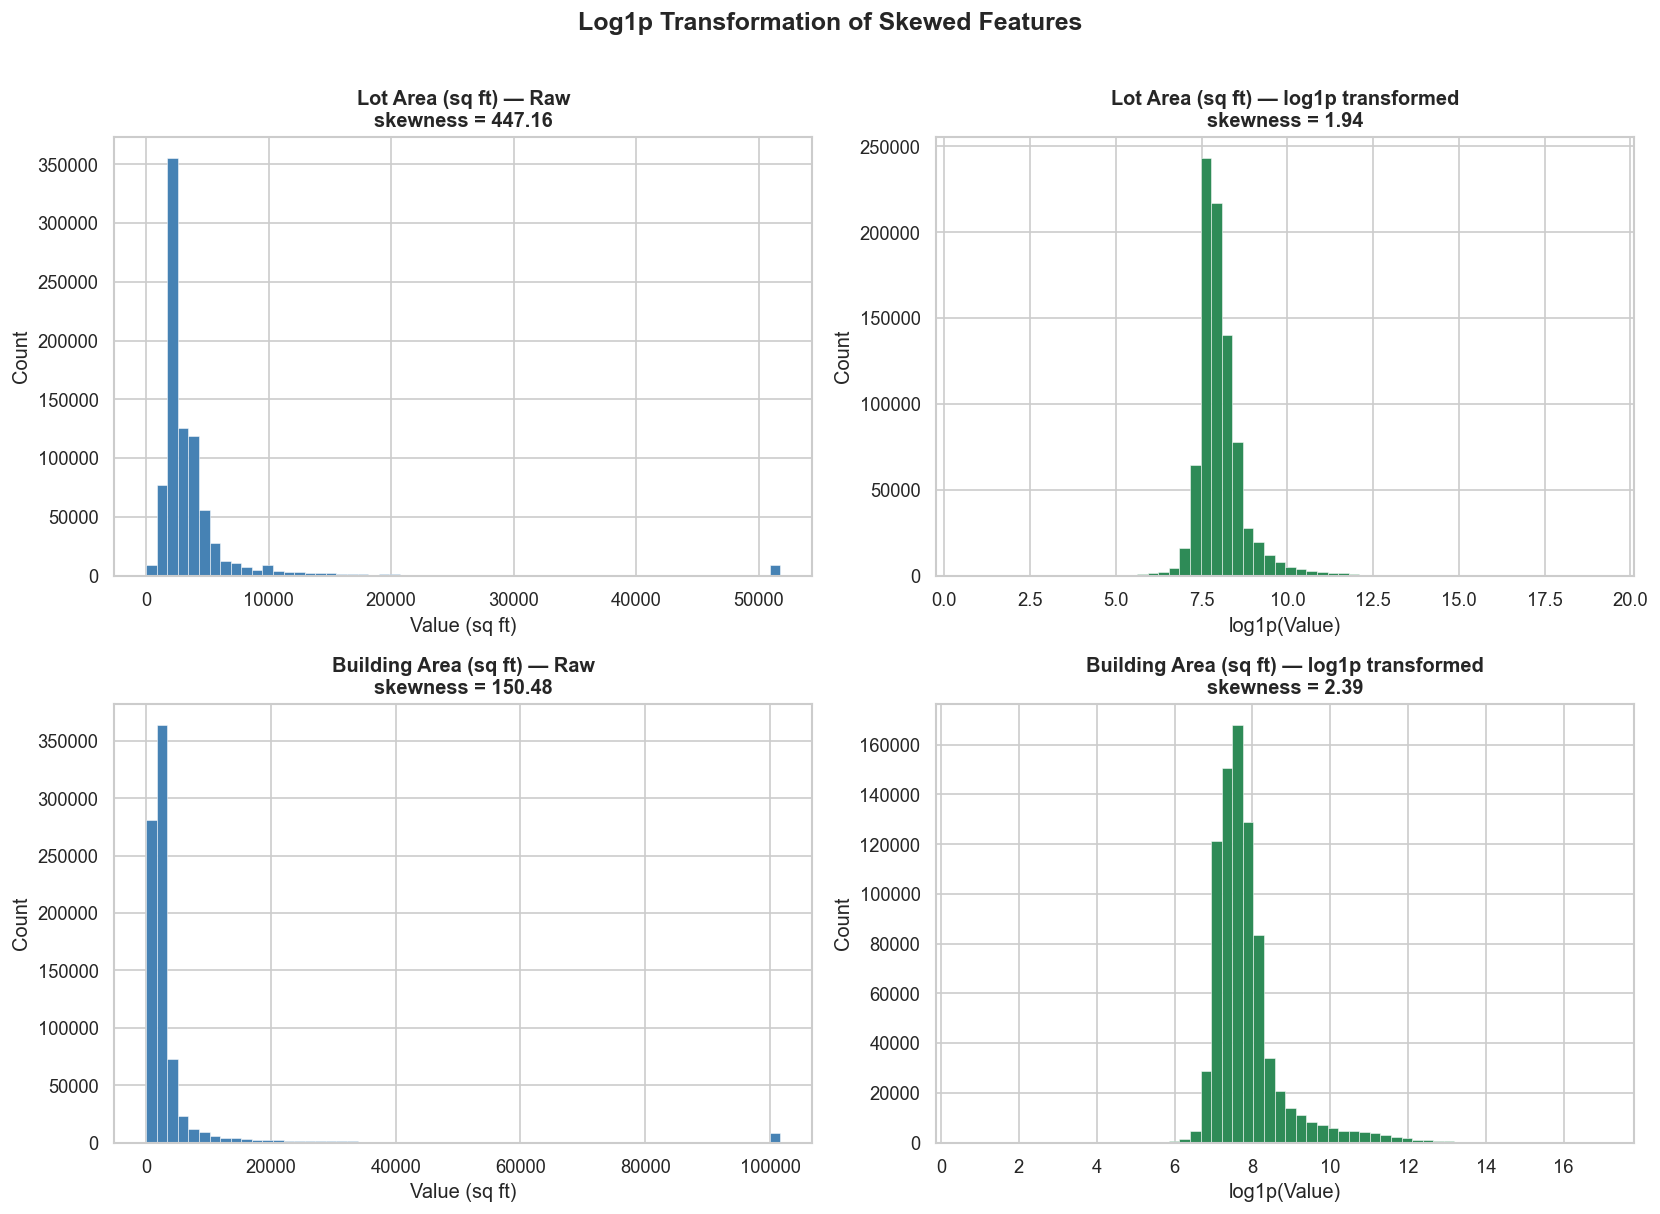

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Log1p Transformation of Skewed Features', fontsize=15, fontweight='bold', y=1.01)

features_to_log = ['lotarea', 'bldgarea']
labels = ['Lot Area (sq ft)', 'Building Area (sq ft)']

for i, (col, label) in enumerate(zip(features_to_log, labels)):
    series = df[col].dropna()
    series = series[series > 0]          # restrict to positive values
    clip_val = series.quantile(0.99)     # clip extreme outliers for display only

    skew_before = round(series.skew(), 2)
    skew_after  = round(np.log1p(series).skew(), 2)

    # Raw distribution (clipped at 99th percentile for readability)
    ax = axes[i, 0]
    ax.hist(series.clip(upper=clip_val), bins=60,
            color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(f'{label} - Raw\nskewness = {skew_before}', fontweight='bold')
    ax.set_xlabel('Value (sq ft)')
    ax.set_ylabel('Count')

    # log1p-transformed distribution
    ax = axes[i, 1]
    ax.hist(np.log1p(series), bins=60,
            color='seagreen', edgecolor='white', linewidth=0.3)
    ax.set_title(f'{label} - log1p transformed\nskewness = {skew_after}', fontweight='bold')
    ax.set_xlabel('log1p(Value)')
    ax.set_ylabel('Count')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '03_lotarea_bldgarea_log_transform.png')
plt.savefig(fig_path, bbox_inches='tight')
print(f'Figure saved to {fig_path}')
plt.show()

**Observation:** Both raw distributions are strongly right-skewed (skewness >> 1),
driven by a small number of extremely large lots and buildings.
After `log1p` transformation the distributions become approximately bell-shaped
(skewness near 0), which makes Euclidean distance a meaningful metric.

The same transformation will be applied in Phase 2 to:
`resarea`, `comarea`, `officearea`, `retailarea`, `garagearea`, `strgearea`,
`unitstotal`, `unitsres`, and the engineered `building_density`.

## 6.3: Categorical Encoding: `landuse`

`landuse` is a categorical feature with a small set of codes representing land use types
(e.g., `01` = One & Two Family Buildings, `05` = Commercial & Office Buildings).
K-Means cannot operate on raw categorical values - they must be numerically encoded.

We first examine the distribution of categories, then demonstrate one-hot encoding.

landuse value counts:
  Code              Count    Share
  ---------------------------------
  1.0             566,773    66.0%
  2.0             131,604    15.3%
  3.0              13,372     1.6%
  4.0              56,427     6.6%
  5.0              21,277     2.5%
  6.0               9,317     1.1%
  7.0               6,352     0.7%
  8.0              12,082     1.4%
  9.0               4,779     0.6%
  10.0              9,244     1.1%
  11.0             24,704     2.9%


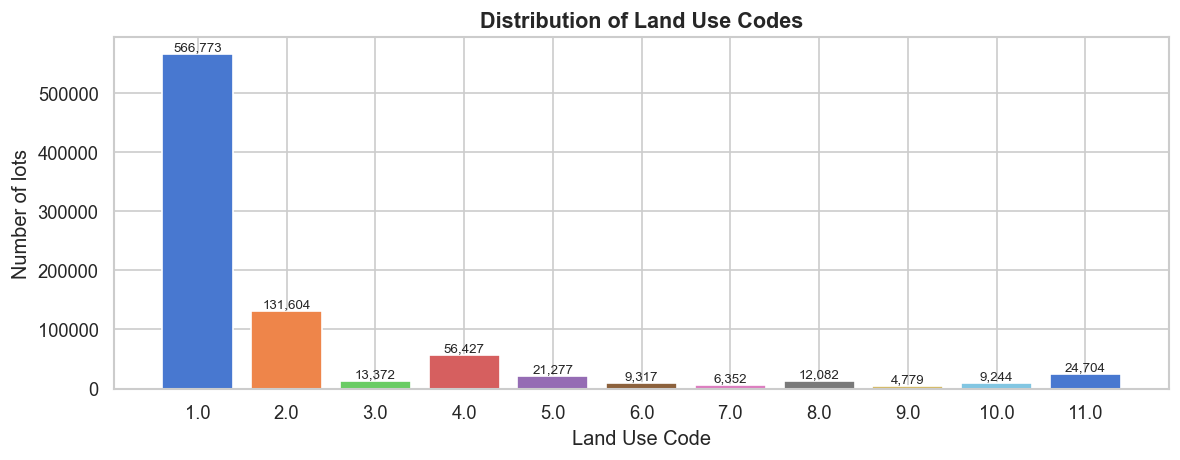

In [6]:
vc = df['landuse'].value_counts().sort_index()
total = len(df)

print('landuse value counts:')
print('  {:<12} {:>10} {:>8}'.format('Code', 'Count', 'Share'))
print('  ' + '-' * 33)
for code, count in vc.items():
    print('  {:<12} {:>10,} {:>7.1f}%'.format(str(code), count, count / total * 100))

fig, ax = plt.subplots(figsize=(10, 4))
palette = sns.color_palette('muted', len(vc))
bars = ax.bar(vc.index.astype(str), vc.values, color=palette)
ax.set_title('Distribution of Land Use Codes', fontsize=13, fontweight='bold')
ax.set_xlabel('Land Use Code')
ax.set_ylabel('Number of lots')
for bar, val in zip(bars, vc.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val + 1000,
        f'{val:,}', ha='center', va='bottom', fontsize=8
    )
plt.tight_layout()
plt.show()

In [7]:
# One-hot encoding demonstration on a small sample
sample = df[['landuse']].dropna().head(8).copy()
encoded = pd.get_dummies(sample, columns=['landuse'], prefix='landuse', dtype=int)

print('Original:')
print(sample.to_string())
print('\nAfter one-hot encoding:')
print(encoded.to_string())
print('\nColumns created:', list(encoded.columns))
print('Number of binary columns added:', len(encoded.columns))

Original:
   landuse
0      1.0
1      1.0
2      1.0
3      2.0
4      2.0
5      5.0
6      8.0
7      6.0

After one-hot encoding:
   landuse_1.0  landuse_2.0  landuse_5.0  landuse_6.0  landuse_8.0
0            1            0            0            0            0
1            1            0            0            0            0
2            1            0            0            0            0
3            0            1            0            0            0
4            0            1            0            0            0
5            0            0            1            0            0
6            0            0            0            0            1
7            0            0            0            1            0

Columns created: ['landuse_1.0', 'landuse_2.0', 'landuse_5.0', 'landuse_6.0', 'landuse_8.0']
Number of binary columns added: 5


**Encoding strategy - One-hot vs Label encoding:**

| Approach | Principle | Verdict |
|---|---|---|
| **Label encoding** | Map each category to an integer (01 -> 1, 02 -> 2, ...) | **Rejected:** implies an ordinal relationship that does not exist between land use types |
| **One-hot encoding** | One binary column per category | **Chosen:** treats each land use type as an independent, unordered dimension |

**Why one-hot is correct here:**  
Land use codes are nominal, not ordinal. Code `04` (Mixed Residential & Commercial) is not
'greater than' code `01` (One & Two Family Buildings). Label encoding would introduce a false
numerical ordering that would directly bias K-Means distance calculations.

One-hot encoding adds approximately 11 binary columns - acceptable given the low cardinality
of `landuse`. All resulting columns will be standardised before clustering.

## 6.4: Standardisation

**Why StandardScaler is mandatory before K-Means:**

K-Means assigns each point to the nearest centroid using Euclidean distance.
If features have very different scales:
- `lotarea` ranges from ~100 to 1,000,000+ sq ft
- `numfloors` ranges from 1 to ~100

Then `lotarea` alone dominates every distance calculation and `numfloors` becomes
irrelevant to cluster assignment. The algorithm would effectively ignore 14 of 15 features.

**StandardScaler** transforms each feature to: mean = 0, std = 1

    x_scaled = (x - mean) / std

Every feature then contributes equally to Euclidean distance, regardless of its original unit.

> **Note:** Final scaling will be applied in Phase 2 (Preprocessing).
> The demonstration below uses a representative sample only.

In [8]:
demo_cols = ['lotarea', 'bldgarea', 'numfloors', 'building_age']

sample_raw = df[demo_cols].dropna().head(2000).copy()

scaler = StandardScaler()
scaled_values = scaler.fit_transform(sample_raw)
sample_scaled = pd.DataFrame(
    scaled_values,
    columns=[c + '_scaled' for c in demo_cols]
)

print('BEFORE StandardScaler (first 2,000 rows):')
print(sample_raw.describe().round(2))

print('\nAFTER StandardScaler (first 2,000 rows):')
print(sample_scaled.describe().round(4))

BEFORE StandardScaler (first 2,000 rows):
         lotarea   bldgarea  numfloors  building_age
count    2000.00    2000.00    2000.00       2000.00
mean     4628.53    6129.95      11.27         88.99
std     16845.73   23952.99      38.26         26.01
min       526.00       0.00       1.00          1.00
25%      2000.00    1662.00       2.00         76.00
50%      2600.00    2400.00       2.00        101.00
75%      4000.00    3202.00       3.00        103.00
max    593357.00  500000.00     575.00        175.00

AFTER StandardScaler (first 2,000 rows):
       lotarea_scaled  bldgarea_scaled  numfloors_scaled  building_age_scaled
count       2000.0000        2000.0000         2000.0000            2000.0000
mean           0.0000          -0.0000            0.0000               0.0000
std            1.0003           1.0003            1.0003               1.0003
min           -0.2436          -0.2560           -0.2684              -3.3838
25%           -0.1561          -0.1866           

**Observation:** After scaling, every feature has mean = 0 and std = 1, regardless of its
original range. K-Means will now compute distances in a balanced feature space where each
variable contributes proportionally to the final cluster assignment.

StandardScaler is applied **after** `log1p` transformation - the two operations are
complementary: `log1p` corrects distributional skewness, StandardScaler corrects scale.

---
# Section 7: Unbalanced Data

Class imbalance in categorical features can bias K-Means: if one category accounts for
the vast majority of observations, clusters tend to reflect subtle variations within that
majority class, masking distinct but smaller groups.

We analyse the two main categorical dimensions: `borough` (geographical) and `landuse` (functional).

## 7.1: Borough Distribution

`borough` identifies which of the five NYC boroughs a lot belongs to.
It is **excluded** from K-Means input and reserved for post-clustering analysis.
We analyse it here to understand geographic representation in the dataset.

Figure saved to reports/figures/03_borough_distribution.png


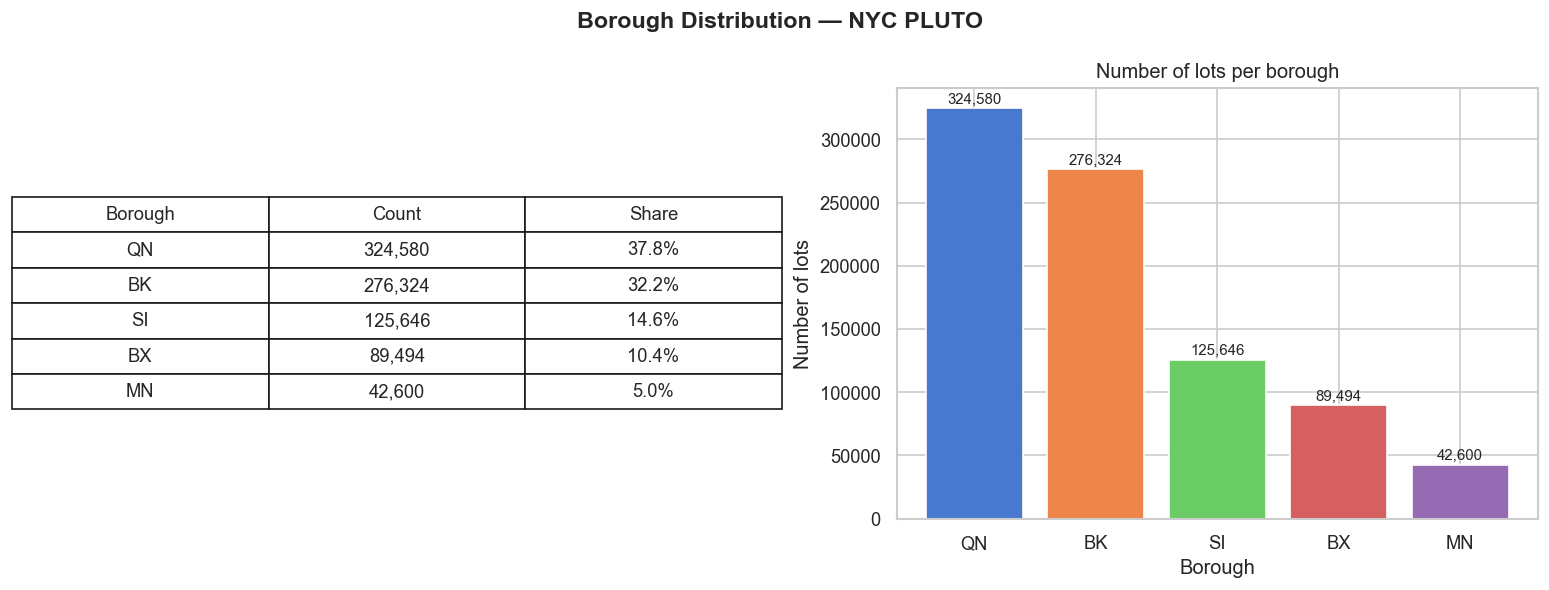

In [9]:
borough_counts = df['borough'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Borough Distribution - NYC PLUTO', fontsize=14, fontweight='bold')

# Left: summary table
axes[0].axis('off')
tbl_data = [
    [b, '{:,}'.format(n), '{:.1f}%'.format(n / len(df) * 100)]
    for b, n in borough_counts.items()
]
tbl = axes[0].table(
    cellText=tbl_data,
    colLabels=['Borough', 'Count', 'Share'],
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.9)

# Right: bar chart
palette = sns.color_palette('muted', len(borough_counts))
bars = axes[1].bar(borough_counts.index, borough_counts.values, color=palette)
axes[1].set_title('Number of lots per borough')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Number of lots')
for bar, val in zip(bars, borough_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, val + 1500,
        '{:,}'.format(val), ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '03_borough_distribution.png')
plt.savefig(fig_path, bbox_inches='tight')
print(f'Figure saved to {fig_path}')
plt.show()

**Observation:** The dataset is geographically imbalanced - Brooklyn and Queens together
represent the majority of lots, while Staten Island is the least represented borough.

**Impact on our model:**  
Since `borough` is excluded from K-Means input, this imbalance will **not directly bias
cluster formation**. However, it is important context for Phase 4: when we map clusters
back to geography, we should account for the fact that some clusters may over-represent
dense urban boroughs (Manhattan, Brooklyn) simply because they contribute more observations.

## 7.2: Land Use Distribution

`landuse` **is** used as a K-Means input feature (after one-hot encoding).
Understanding its imbalance is critical: a dominant category may cause K-Means to form
multiple clusters within that category while collapsing all minority types into one cluster.

Figure saved to reports/figures/03_landuse_distribution.png


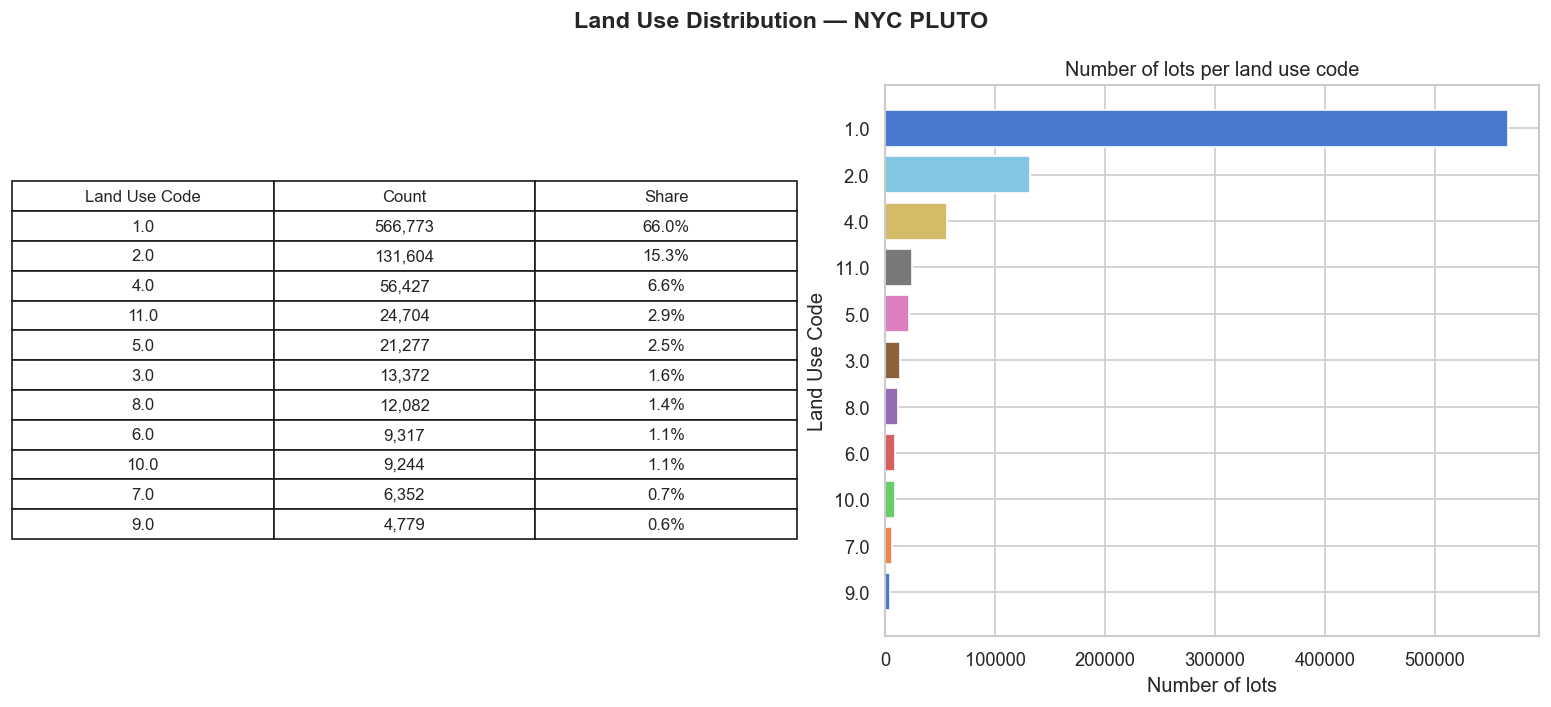

In [10]:
lu_counts = df['landuse'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Land Use Distribution - NYC PLUTO', fontsize=14, fontweight='bold')

# Left: summary table (sorted descending)
axes[0].axis('off')
tbl_data = [
    [str(lu), '{:,}'.format(n), '{:.1f}%'.format(n / len(df) * 100)]
    for lu, n in lu_counts.items()
]
tbl = axes[0].table(
    cellText=tbl_data,
    colLabels=['Land Use Code', 'Count', 'Share'],
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)

# Right: horizontal bar chart (sorted ascending for readability)
lu_sorted = lu_counts.sort_values(ascending=True)
palette = sns.color_palette('muted', len(lu_sorted))
axes[1].barh(lu_sorted.index.astype(str), lu_sorted.values, color=palette)
axes[1].set_title('Number of lots per land use code')
axes[1].set_xlabel('Number of lots')
axes[1].set_ylabel('Land Use Code')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '03_landuse_distribution.png')
plt.savefig(fig_path, bbox_inches='tight')
print(f'Figure saved to {fig_path}')
plt.show()

**Observation:** The `landuse` distribution is strongly unbalanced. Residential codes
(typically codes 01 and 02) account for the large majority of NYC lots,
while commercial, industrial, and mixed-use types are substantially under-represented.

**Impact on K-Means and our strategy:**

| Risk | Our mitigation |
|---|---|
| K-Means may form multiple sub-clusters within the dominant residential category | Acceptable - these sub-clusters may reveal meaningful residential typologies (dense vs. sparse, old vs. new) |
| Minority land use types (industrial, parking) may be merged into one cluster | Monitor cluster purity in Phase 4; examine whether minority types appear as distinct clusters |
| Resampling (SMOTE, undersampling) could correct the imbalance | Rejected - the imbalance reflects real NYC urban composition, not a data collection artefact |

After one-hot encoding and StandardScaler, each land use binary column will have mean ~0
and std ~1, which partially mitigates the dominance effect in distance calculations.

---
# Section 8: Final Synthesis & Preprocessing Recommendations

This section consolidates the findings from all three EDA notebooks and defines
the complete feature set and preprocessing pipeline to be implemented in Phase 2.

## 8.1: Key EDA Findings

### From Notebook 1: Dataset Discovery

> **[PLACEHOLDER: to be completed once Notebook 1 is finalised]**
>
> Expected content:
> - Overall missing value rates by feature (columns to keep / drop / impute)
> - Features with critical missingness (> X%) recommended for removal
> - Identified data quality issues: incorrect types, inconsistent codes, duplicate rows

### From Notebook 2: Visualizations and Outliers

> **[PLACEHOLDER: to be completed once Notebook 2 is finalised]**
>
> Expected content:
> - Most skewed features (candidates for log transformation) - confirmed or extended
> - Outlier boundaries (IQR thresholds) per feature and number of rows affected
> - Highly correlated feature pairs to consider removing

### From Notebook 3: Feature Engineering

- 4 new features created: `building_age`, `building_density`, `residential_ratio`, `value_per_sqft`
- `log1p` transformation validated as essential for area-based and count features
- One-hot encoding chosen for `landuse` (nominal, not ordinal)
- StandardScaler demonstrated as necessary to equalise feature scales before K-Means
- Borough imbalance: does not bias clustering (`borough` excluded from K-Means input)
- Land use imbalance: acknowledged; cluster composition will be examined carefully in Phase 4

## 8.2: Final Feature Selection

### K-Means Clustering Input (15 original + 3 engineered features)

| # | Feature | Type | Preprocessing |
|---|---|---|---|
| 1 | `lotarea` | Numerical | log1p + StandardScaler |
| 2 | `bldgarea` | Numerical | log1p + StandardScaler |
| 3 | `numfloors` | Numerical | StandardScaler |
| 4 | `lotfront` | Numerical | StandardScaler |
| 5 | `lotdepth` | Numerical | StandardScaler |
| 6 | `unitstotal` | Numerical | log1p + StandardScaler |
| 7 | `unitsres` | Numerical | log1p + StandardScaler |
| 8 | `resarea` | Numerical | log1p + StandardScaler |
| 9 | `comarea` | Numerical | log1p + StandardScaler |
| 10 | `officearea` | Numerical | log1p + StandardScaler |
| 11 | `retailarea` | Numerical | log1p + StandardScaler |
| 12 | `garagearea` | Numerical | log1p + StandardScaler |
| 13 | `strgearea` | Numerical | log1p + StandardScaler |
| 14 | `landuse` | Categorical | One-hot encoding + StandardScaler |
| 15 | `building_age` | Numerical (engineered) | StandardScaler |
| 16 | `building_density` | Numerical (engineered) | log1p + StandardScaler |
| 17 | `residential_ratio` | Numerical (engineered) | StandardScaler |

### Post-Clustering Interpretation Only

| Feature | Purpose |
|---|---|
| `borough` | Geographic distribution of clusters across the 5 boroughs |
| `zipcode` | Neighbourhood-level cluster mapping |
| `cd` | Community district analysis |
| `latitude`, `longitude` | Spatial visualisation of clusters on a map |
| `assesstot` | Raw property value profile per cluster |
| `value_per_sqft` | Normalised property value per cluster (engineered) |

## 8.3: Recommended Preprocessing Pipeline

To be implemented in `notebooks/02_preprocessing/preprocessing.ipynb`.
Steps must be applied in this exact order:

**Step 1: Drop rows with critical missing values**  
Remove rows where key clustering features are missing. Exact thresholds to be
defined based on the analysis in Notebook 1.

**Step 2: Handle outliers**  
Apply IQR-based Winsorization (capping at Q1 - 1.5*IQR / Q3 + 1.5*IQR) on features
identified in Notebook 2. Prefer capping over deletion to preserve dataset size.

**Step 3: Apply log1p to skewed features**  
Features: `lotarea`, `bldgarea`, `unitstotal`, `unitsres`, `resarea`, `comarea`,
`officearea`, `retailarea`, `garagearea`, `strgearea`.

**Step 4: Create engineered features**  
Regenerate `building_age`, `building_density`, `residential_ratio` from the
clean dataset (after Steps 1-3). Apply log1p to `building_density`.

**Step 5: One-hot encode `landuse`**  
Use `pd.get_dummies(df, columns=['landuse'], prefix='landuse', drop_first=False, dtype=int)`.

**Step 6: StandardScaler on all clustering features**  
Fit on the full dataset (no train/test split for unsupervised learning).
Store the fitted scaler for inverse-transforming cluster centroids in Phase 4.

**Output:** `data/processed/pluto_preprocessed.csv` - the final scaled feature matrix
ready for PCA (Phase 3) and K-Means (Phase 4).

In [11]:
# Save the dataframe with all engineered features for use in Phase 2
output_path = 'data/processed/pluto_engineered.csv'
df.to_csv(output_path, index=False)

print(f'Engineered dataframe saved to: {output_path}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns added in this notebook: {new_features}')

Engineered dataframe saved to: data/processed/pluto_engineered.csv
Shape: 858,644 rows x 105 columns
Columns added in this notebook: ['building_age', 'building_density', 'residential_ratio', 'value_per_sqft']


## 8.4: Next Steps

| Phase | Notebook | Key Tasks |
|---|---|---|
| **Phase 2: Preprocessing** | `02_preprocessing/preprocessing.ipynb` | Implement Steps 1-6 of the pipeline; output clean, scaled feature matrix |
| **Phase 3: Dimensionality Reduction** | `03_dimensionality_reduction/pca.ipynb` | PCA to retain 80-90% of variance; t-SNE or UMAP for 2D cluster visualisation |
| **Phase 4: Clustering** | `04_clustering/clustering.ipynb` | K-Means with elbow method + silhouette score; cluster profiling; geographic distribution |

The research question will be answered in Phase 4: each K-Means cluster will be
characterised by its dominant physical, functional, and geographical traits,
defining the homogeneous urban building profiles of New York City.